In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline

In [9]:
data = pd.read_csv("book_reviews.csv")

data.head()

,text,label
0,Fascinating view into the past: This book is f...,__label__2
1,A very amusing look at the past: I was hoping ...,__label__2
2,Didn't like...: I didn't like this version of ...,__label__1
3,"Two Divas,that should shut up!: Here are two s...",__label__1
4,Movie Version is Much better!: The movie versi...,__label__1


In [10]:
data['text'][0]

"Fascinating view into the past: This book is fascinating for anyone at all interested in New Zealand history or a general account of life in the past. It is surprisingly well written for what is just a series of letters, and gives a real insight into life as a pioneer in the 1860s, with all its highs and lows. You'll laugh at the author's first attempts at baking, and cry with her as she digs dead lambs from a snowdrift. It's a wonderful book and I heartily recommend it."

In [11]:
data["label_clean"] = data['label'].str.extract(r'__label__(\d+)').astype(int)

In [12]:
data.head()

,text,label,label_clean
0,Fascinating view into the past: This book is f...,__label__2,2
1,A very amusing look at the past: I was hoping ...,__label__2,2
2,Didn't like...: I didn't like this version of ...,__label__1,1
3,"Two Divas,that should shut up!: Here are two s...",__label__1,1
4,Movie Version is Much better!: The movie versi...,__label__1,1


In [16]:
data['text_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['text']).lower(), axis=1)

In [17]:
data.head()

,text,label,label_clean,text_clean
0,Fascinating view into the past: This book is f...,__label__2,2,fascinating view into the past this book is fa...
1,A very amusing look at the past: I was hoping ...,__label__2,2,a very amusing look at the past i was hoping f...
2,Didn't like...: I didn't like this version of ...,__label__1,1,didnt like i didnt like this version of the so...
3,"Two Divas,that should shut up!: Here are two s...",__label__1,1,two divasthat should shut up here are two song...
4,Movie Version is Much better!: The movie versi...,__label__1,1,movie version is much better the movie version...


In [23]:
vader_sentiment = SentimentIntensityAnalyzer()

In [40]:
data['vader_sentiment_score'] = data['text_clean'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])

In [41]:
data.head()

,text,label,label_clean,text_clean,vader_sentiment_score
0,Fascinating view into the past: This book is f...,__label__2,2,fascinating view into the past this book is fa...,0.9274
1,A very amusing look at the past: I was hoping ...,__label__2,2,a very amusing look at the past i was hoping f...,0.8932
2,Didn't like...: I didn't like this version of ...,__label__1,1,didnt like i didnt like this version of the so...,0.6788
3,"Two Divas,that should shut up!: Here are two s...",__label__1,1,two divasthat should shut up here are two song...,0.5267
4,Movie Version is Much better!: The movie versi...,__label__1,1,movie version is much better the movie version...,0.9274


In [43]:
bins = [-1, -0.1, 0.1, 1]
names = ["negative", 'neutral', 'postive']

data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins=bins, labels=names)

<Axes: xlabel='vader_sentiment_label'>

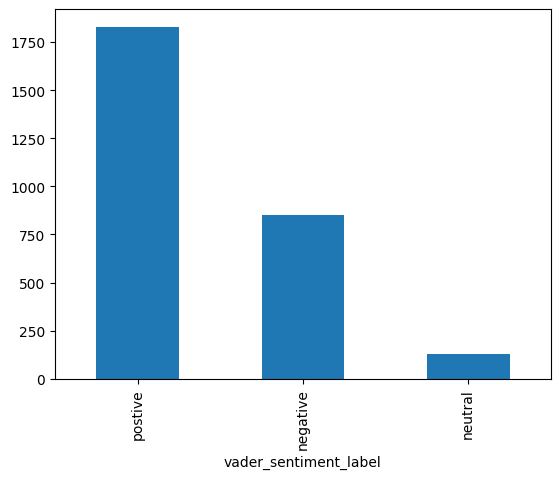

In [45]:
data['vader_sentiment_label'].value_counts().plot.bar()

In [47]:
transformer_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [50]:
transformer_labels = []

for text in data['text_clean'].values:
  sentiment_list = transformer_pipeline(text)
  sentiment_label = [sent['label'] for sent in sentiment_list]
  transformer_labels.append(sentiment_label)

In [51]:
data['transformer_sentiment_label'] = transformer_labels

<Axes: xlabel='transformer_sentiment_label'>

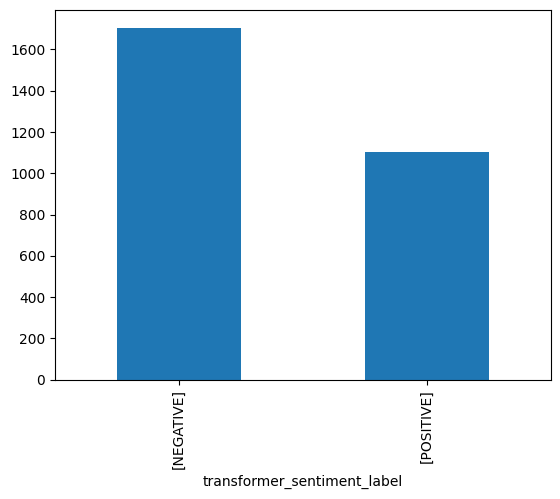

In [52]:
data['transformer_sentiment_label'].value_counts().plot.bar()